# Stage 9 — Sensitivity Analysis

Checks how much the frozen method's result depends on choices that could reasonably have gone another way: the catchment-aggregation method and its distance parameter, the weight emphasis, whether rainfall is included, and which year's land use is used.

All Mole Creek results here cover the **Mole Creek karst only**. The 3 km buffer is the computation extent, but the neighbouring systems inside it (Lorinna, Stockers Plain, Quamby Brook, Golden Valley) are masked out of the correlations, rankings and trend metrics.

Correlations are reported over all valid cells and restricted to cells where either surface is nonzero. Within the Mole Creek karst the two coincide, because essentially every cell has risk above zero.

In [1]:
from pathlib import Path
import os
import sys
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.io import MemoryFile
from rasterio.mask import mask
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
from landuse import fetch_landuse_pressure
from karst import aggregate_pressure_by_system, rasterize_max, in_mole_creek_focus, mole_creek_focus_mask
from hydro import slope_degrees, slope_risk_multiplier

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float)
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "landuse_pressure_mc_2020_EPSG7855.tif") as src:
    pressure_2020 = src.read(1).astype(float)
    pressure_nodata = src.nodata
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1)
    dem_nodata = src.nodata
    transform = src.transform
    shape = dem.shape

karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# The 3 km buffer is the computation extent; results are reported for the Mole Creek karst only.
focus = mole_creek_focus_mask(karst_mc, shape, transform)
valid_buffer = dem != dem_nodata
valid = valid_buffer & focus
karst_cells = (intensity > 0) & focus
karst_only = karst_mc[(karst_mc["karst_intensity"] > 0) & in_mole_creek_focus(karst_mc)].copy()

intensity_norm = intensity / 4.0
connectivity_norm = connectivity / 3.0
intrinsic = intensity_norm * connectivity_norm
effective_pressure_2020 = aggregate_pressure_by_system(karst_mc, pressure_2020, transform, pressure_nodata)
pressure_norm_2020 = effective_pressure_2020 / 3.0
slope_factor = slope_risk_multiplier(slope_degrees(dem, dem_nodata, abs(transform.a)))
baseline_risk = np.where(valid, intrinsic * pressure_norm_2020 * slope_factor, np.nan)

def corr_both(a, b, valid_mask):
    """Correlation over all valid cells, and restricted to cells where
    either surface is nonzero -- the all-cells figure is included for
    comparison, but the nonzero one is the headline (see Stage 8)."""
    m1 = valid_mask & ~np.isnan(a) & ~np.isnan(b)
    m2 = m1 & ((a > 0) | (b > 0))
    r_all = np.corrcoef(a[m1], b[m1])[0, 1]
    r_nz = np.corrcoef(a[m2], b[m2])[0, 1] if m2.sum() > 1 else np.nan
    return r_all, r_nz

def named_area_ranking(risk, valid_mask):
    out_profile = {"driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
                   "dtype": "float32", "crs": "EPSG:7855", "transform": transform, "nodata": -9999}
    rows = []
    with MemoryFile() as mem:  # in memory: no temporary file on the shared drive
        with mem.open(**out_profile) as dst:
            dst.write(np.where(valid_mask & ~np.isnan(risk), risk, -9999).astype("float32"), 1)
        with mem.open() as src:
            for name, group in karst_only.groupby("KNAME"):
                out_image, _ = mask(src, list(group.geometry), crop=True, nodata=-9999)
                v = out_image[0]; v = v[v != -9999]
                rows.append({"KNAME": name, "mean_risk": v.mean() if len(v) else np.nan})
    return pd.DataFrame(rows).sort_values("mean_risk", ascending=False).reset_index(drop=True)

## 9.1 Catchment aggregation

The frozen method uses catchment-aggregated pressure (Stage 6): each karst cell takes the mean pressure across its whole named system, so land use in the catchment reaches the karst. This section tests that choice against raw per-pixel pressure, and tests the 1 km distance threshold the aggregation depends on.

In [2]:
# Without aggregation: raw per-pixel pressure, no catchment reach-through
no_agg_risk = np.where(valid, intrinsic * (pressure_2020 / 3.0) * slope_factor, np.nan)
r_all, r_nz = corr_both(baseline_risk, no_agg_risk, valid)
print(f"Aggregated vs. raw-pixel pressure: all-cells r={r_all:.4f}, nonzero-restricted r={r_nz:.4f}")

print("\nmax_gap_m threshold sensitivity (Mole Creek):")
for gap in [500, 1000, 2000, 5000]:
    eff = aggregate_pressure_by_system(karst_mc, pressure_2020, transform, pressure_nodata, max_gap_m=gap)
    risk_g = intrinsic * (eff / 3.0) * slope_factor
    mean_karst = np.nanmean(np.where(karst_cells & valid, risk_g, np.nan))
    print(f"  max_gap_m={gap}m: mean risk on karst cells = {mean_karst:.4f}")

Aggregated vs. raw-pixel pressure: all-cells r=0.0923, nonzero-restricted r=0.0923

max_gap_m threshold sensitivity (Mole Creek):
  max_gap_m=500m: mean risk on karst cells = 0.1950


  max_gap_m=1000m: mean risk on karst cells = 0.1950
  max_gap_m=2000m: mean risk on karst cells = 0.1950


  max_gap_m=5000m: mean risk on karst cells = 0.1950


**Result: this is the largest sensitivity in this stage.** Aggregated and raw-pixel pressure correlate at only r = 0.092 over the Mole Creek karst, so the two produce essentially unrelated spatial patterns. Every weight and rainfall variant below stays above r = 0.97.

Catchment aggregation is therefore the most consequential methodological choice in the pipeline. It was adopted in Stage 6 because raw-pixel pressure cannot represent catchment land use reaching the karst. This test measures the size of that choice rather than which version is more correct.

The `max_gap_m` threshold makes no difference at Mole Creek: mean risk is identical from 500 m to 5000 m. The threshold was added to separate the placeholder names ("Several", "Various") that occur statewide, and Mole Creek has none, so it matters only at the statewide scale.

## 9.2 Weight sensitivity

The frozen method (Stage 6) is an equal-weight product: risk = intensity_norm × connectivity_norm × pressure_norm (exponents 1,1,1). Baseline here reproduces that exactly.

In [3]:
SCENARIOS = {
    "Baseline (= frozen method)": (1, 1, 1),
    "Susceptibility-emphasised": (2, 1, 1),
    "Connectivity-emphasised": (1, 2, 1),
    "Pressure-emphasised": (1, 1, 2),
}

weight_risk = {}
weight_rankings = {}
for scenario, (wi, wc, wp) in SCENARIOS.items():
    with np.errstate(invalid="ignore"):
        risk = np.where(valid, (intensity_norm**wi) * (connectivity_norm**wc) * (pressure_norm_2020**wp) * slope_factor, np.nan)
    weight_risk[scenario] = risk
    weight_rankings[scenario] = named_area_ranking(risk, valid)

print("Correlation of each scenario against baseline (all-cells | nonzero-restricted):")
for scenario, risk in weight_risk.items():
    if scenario == "Baseline (= frozen method)":
        continue
    r_all, r_nz = corr_both(baseline_risk, risk, valid)
    print(f"  {scenario}: {r_all:.4f} | {r_nz:.4f}")

print("\nTop-4 named areas under each scenario:")
for scenario, df in weight_rankings.items():
    print(f"\n{scenario}:")
    print(df.head(4).to_string(index=False))

Correlation of each scenario against baseline (all-cells | nonzero-restricted):
  Susceptibility-emphasised: 0.9793 | 0.9793
  Connectivity-emphasised: 0.9730 | 0.9730
  Pressure-emphasised: 0.9978 | 0.9978

Top-4 named areas under each scenario:

Baseline (= frozen method):
                       KNAME  mean_risk
Mole Creek  (Chudleigh Hill)   0.267796
                  Mole Creek   0.201520
     Meander - Western Creek   0.088970

Susceptibility-emphasised:
                       KNAME  mean_risk
Mole Creek  (Chudleigh Hill)   0.267796
                  Mole Creek   0.189384
     Meander - Western Creek   0.022243

Connectivity-emphasised:
                       KNAME  mean_risk
Mole Creek  (Chudleigh Hill)   0.178531
                  Mole Creek   0.168286
     Meander - Western Creek   0.088970

Pressure-emphasised:
                       KNAME  mean_risk
Mole Creek  (Chudleigh Hill)   0.194382
                  Mole Creek   0.095040
     Meander - Western Creek   0.051039


**Result:** correlations with the baseline are 0.973 (connectivity-emphasised), 0.979 (susceptibility-emphasised) and 0.998 (pressure-emphasised), far above the aggregation test. Weight choice is a secondary sensitivity. The order of the three Mole Creek areas is the same in every scenario.

## 9.3 Rainfall experiment

Tests `KAVRAIN` as a [0.5, 1.0] modifier on risk, using min-max normalisation across the karst polygons in the buffer. The per-area rainfall values are printed alongside the result, because the scaling choice and the range it is built on decide the outcome.

In [4]:
karst_rain = karst_mc[karst_mc["karst_intensity"] > 0]
rain_min, rain_max = karst_rain["KAVRAIN"].min(), karst_rain["KAVRAIN"].max()
print(f"KAVRAIN range at actual karst polygons: {rain_min}-{rain_max} mm")
print("\nPer-area KAVRAIN (so the normalisation's effect is visible, not just asserted):")
print(karst_rain.groupby("KNAME")["KAVRAIN"].mean().sort_values(ascending=False))

karst_mc["rain_norm"] = ((karst_mc["KAVRAIN"] - rain_min) / (rain_max - rain_min)).clip(0, 1)
karst_mc.loc[karst_mc["karst_intensity"] == 0, "rain_norm"] = 0

rain_raster = rasterize_max(karst_mc, "rain_norm", shape, transform, fill=0, dtype="float32")
risk_with_rain = np.where(valid, intensity_norm * connectivity_norm * pressure_norm_2020 * slope_factor * (0.5 + 0.5 * rain_raster), np.nan)

r_all, r_nz = corr_both(baseline_risk, risk_with_rain, valid)
print(f"\nCorrelation baseline vs. with-rainfall: all-cells={r_all:.4f}, nonzero-restricted={r_nz:.4f}")

rain_ranking = named_area_ranking(risk_with_rain, valid)
print("\nWith-rainfall ranking:")
print(rain_ranking.to_string(index=False))

KAVRAIN range at actual karst polygons: 1050-1662 mm

Per-area KAVRAIN (so the normalisation's effect is visible, not just asserted):
KNAME
Lorinna                                  1662.000000
Golden Valley                            1061.000000
Meander - Western Creek                  1061.000000
Quamby Brook                             1061.000000
Stockers Plain (Muddy Ck; Golden Vly)    1061.000000
Mole Creek                               1053.265625
Mole Creek  (Chudleigh Hill)             1050.000000
Name: KAVRAIN, dtype: float64

Correlation baseline vs. with-rainfall: all-cells=0.9999, nonzero-restricted=0.9999



With-rainfall ranking:
                       KNAME  mean_risk
Mole Creek  (Chudleigh Hill)   0.133898
                  Mole Creek   0.101196
     Meander - Western Creek   0.045285


**Result:** within the Mole Creek karst, rainfall is almost constant (about 1050 to 1061 mm), so the modifier is close to 0.5 everywhere and the risk pattern is unchanged (r = 0.9999, same ranking). The test is uninformative at Mole Creek.

The normalisation range (1050 to 1662 mm) comes from the neighbouring karst in the buffer: Lorinna has the dataset maximum rainfall (1662 mm). An earlier version of this stage included Lorinna and saw it overtake Mole Creek (Chudleigh Hill) when rainfall was added. That swap came from the min-max scaling placing the wettest neighbour at 1.0 and the driest Mole Creek area at 0.5, not from an independent rainfall effect. Rainfall could only be tested meaningfully across areas that differ in it, which means statewide.

## 9.4 Multi-year land-use/risk trend

Mole Creek: the full annual series (1988–2024). Statewide: every 5 years. For Mole Creek the share of high-pressure land is computed over the whole 3 km buffer (context) and over the Mole Creek karst; mean risk is computed over the karst only. Statewide, both metrics are computed over all land and over karst cells only.

In [5]:
mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")
bbox_mc = mole_creek.to_crs("EPSG:4326").total_bounds.tolist()

years = list(range(1988, 2025))
trend_rows = []
t_start = time.time()
for year in years:
    pressure = fetch_landuse_pressure(bbox_mc, year, outpath / "dem_mc_EPSG7855.tif", cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_mc, pressure, transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = intrinsic * pressure_norm * slope_factor
    risk_valid = valid & pressure_valid

    trend_rows.append({
        "year": year,
        "pct_high_pressure_buffer": (pressure[valid_buffer & pressure_valid] == 3).mean() * 100,
        "pct_high_pressure_karst": (pressure[karst_cells & valid & pressure_valid] == 3).mean() * 100,
        "mean_risk_karst": np.nanmean(np.where(karst_cells & risk_valid, risk, np.nan)),
    })

mc_trend = pd.DataFrame(trend_rows)
print(f"Fetched {len(years)} years in {time.time()-t_start:.0f}s")
print(mc_trend)

Fetched 37 years in 11s
    year  pct_high_pressure_buffer  pct_high_pressure_karst  mean_risk_karst
0   1988                 21.816431                65.442957         0.218463
1   1989                 23.129264                60.863473         0.217181
2   1990                 19.578426                59.013172         0.207319
3   1991                 17.651196                51.345356         0.200502
4   1992                 17.273340                51.720985         0.199028
5   1993                 19.627081                57.354225         0.208000
6   1994                 20.687633                61.171357         0.212037
7   1995                 19.425237                58.249824         0.208198
8   1996                 20.704783                61.684724         0.213501
9   1997                 19.740824                60.399309         0.210206
10  1998                 15.469871                46.609305         0.193057
11  1999                 12.715772                37

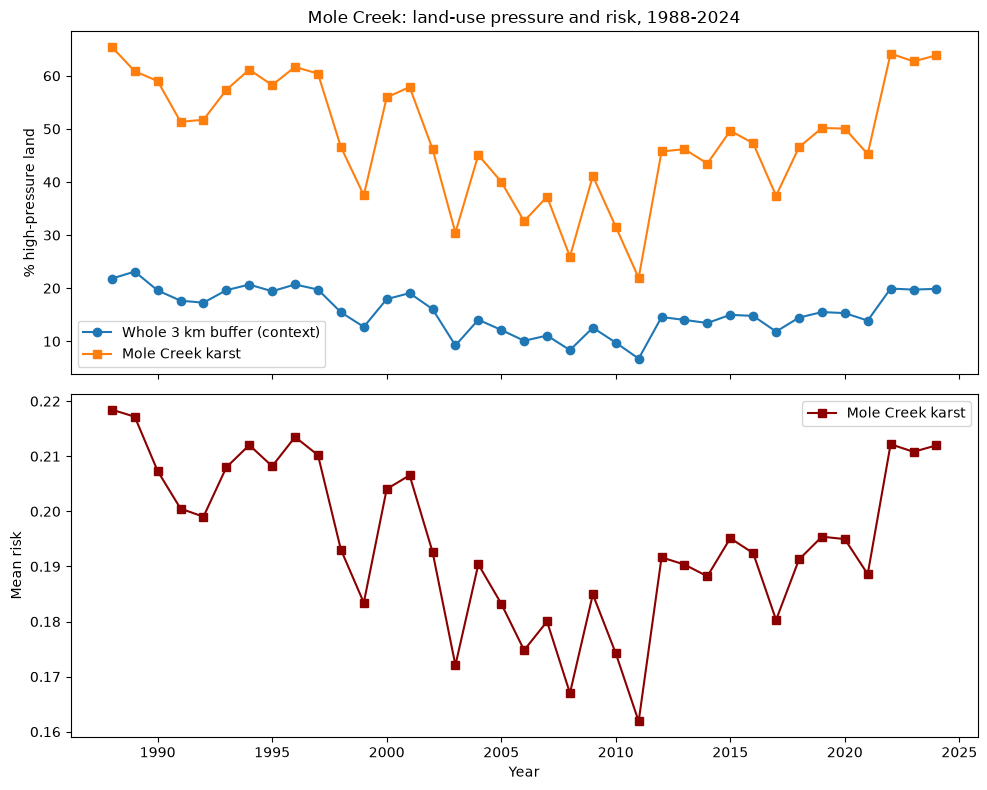

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_buffer"], marker="o", label="Whole 3 km buffer (context)")
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_karst"], marker="s", label="Mole Creek karst")
axes[0].set_ylabel("% high-pressure land")
axes[0].legend()
axes[0].set_title("Mole Creek: land-use pressure and risk, 1988-2024")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk_karst"], marker="s", color="darkred", label="Mole Creek karst")
axes[1].set_ylabel("Mean risk")
axes[1].set_xlabel("Year")
axes[1].legend()
plt.tight_layout()
plt.show()

mc_trend.to_csv(outpath / "stage9_mole_creek_trend.csv", index=False)

**Result:** the trend is U-shaped, and clearer on the Mole Creek karst than over the whole 3 km buffer. High-pressure land on the karst falls from 65% (1988) to a low of 22% (2011) and is back at 64% in 2024, about 3× the buffer-wide percentages (7% to 23%). The Stage 5 finding of rising pressure from 2010 to 2020 is the recovery half of a longer cycle, not a one-way trend.

## 9.5 Does the spatial pattern change year to year?

The trend above shows how the level of risk changes. This section checks whether the spatial pattern changes too, by correlating risk for four representative years against the 2020 baseline.

In [7]:
year_corr_rows = []
for year in [1990, 2000, 2010, 2024]:
    pressure = fetch_landuse_pressure(bbox_mc, year, outpath / "dem_mc_EPSG7855.tif", cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache").astype(float)
    pv = pressure != 255
    eff = aggregate_pressure_by_system(karst_mc, pressure, transform, 255)
    risk_y = intrinsic * np.where(pv, eff / 3.0, np.nan) * slope_factor
    r_all, r_nz = corr_both(baseline_risk, risk_y, valid & pv)
    year_corr_rows.append({"year": year, "r_all": r_all, "r_nonzero": r_nz})

print(pd.DataFrame(year_corr_rows).to_string(index=False))

 year    r_all  r_nonzero
 1990 0.999888   0.999888
 2000 0.999841   0.999841
 2010 0.999908   0.999908
 2024 0.999858   0.999858


**Result:** the spatial pattern is very stable (r > 0.9998 for every year tested) even though the level swings substantially (22% to 65% high-pressure land on the karst; 7% to 23% across the whole buffer). Where risk concentrates barely changes over nearly four decades, because the karst layer is fixed. How much risk there is changes a lot, because land use changes.

## 9.6 Pressure scoring scheme

The pressure scores (water 0, natural 1, cultivated and built-up 3) are a judgement. The literature supports their direction (cultivated land above natural) but gives no numeric weights (see the Methods page). This section re-scores the land-cover classes under alternative schemes and compares the 2020 Mole Creek risk surface with the baseline.

Each scheme is divided by its own maximum score before entering the risk product, so cultivated land is 1.0 in every scheme and only the relative scores differ. Schemes tested:

- **Natural land at 0:** native vegetation, aquatic vegetation and bare ground all score 0, so undisturbed land carries no pressure.
- **Milder contrast:** cultivated and urban land score 2 against natural land at 1 (a 1:2 ratio instead of 1:3).

Not tested:

- **Urban against cultivated land, and bare ground or aquatic vegetation scored differently.** These classes cover under 0.1% of the Mole Creek karst (class shares below), so re-scoring them would change nothing here.
- **A herbaceous-vegetation uplift to stand in for grazed pasture.** DEA's woody/herbaceous descriptor cannot tell grazed pasture from native grassland or moorland, so any such score could not be checked.


In [8]:
SCHEMES = {
    "Baseline (= frozen method)":   {111: 3, 112: 1, 124: 1, 215: 3, 216: 1, 220: 0},
    "Natural land at 0":            {111: 3, 112: 0, 124: 0, 215: 3, 216: 0, 220: 0},
    "Milder contrast (1:2)":        {111: 2, 112: 1, 124: 1, 215: 2, 216: 1, 220: 0},
}

scheme_risk = {}
scheme_rankings = {}
for name, mapping in SCHEMES.items():
    scores = fetch_landuse_pressure(bbox_mc, 2020, outpath / "dem_mc_EPSG7855.tif", reclass=mapping, cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache").astype(float)
    effective = aggregate_pressure_by_system(karst_mc, scores, transform, 255)
    risk = np.where(valid, intrinsic * (effective / max(mapping.values())) * slope_factor, np.nan)
    scheme_risk[name] = risk
    scheme_rankings[name] = named_area_ranking(risk, valid)

base = scheme_risk["Baseline (= frozen method)"]
print(f"Baseline re-computed here matches the frozen Stage 6 surface: {np.allclose(base, baseline_risk, equal_nan=True)}")

print("\nEach scheme against the baseline (all-cells r | nonzero-restricted r | mean risk on karst cells | karst cells with risk > 0):")
for name, risk in scheme_risk.items():
    r_all, r_nz = corr_both(baseline_risk, risk, valid)
    on_karst = risk[karst_cells & valid]
    print(f"  {name}: {r_all:.4f} | {r_nz:.4f} | {np.nanmean(on_karst):.3f} | {(on_karst > 0).mean() * 100:.1f}%")

ranks = pd.DataFrame({name: df.set_index("KNAME")["mean_risk"].rank(ascending=False).astype(int)
                      for name, df in scheme_rankings.items()})
print("\nRank of each named area under each scheme (1 = highest mean risk):")
print(ranks.sort_values("Baseline (= frozen method)").to_string())


Baseline re-computed here matches the frozen Stage 6 surface: True

Each scheme against the baseline (all-cells r | nonzero-restricted r | mean risk on karst cells | karst cells with risk > 0):
  Baseline (= frozen method): 1.0000 | 1.0000 | 0.195 | 100.0%
  Natural land at 0: 0.9933 | 0.9933 | 0.089 | 100.0%
  Milder contrast (1:2): 0.9998 | 0.9998 | 0.248 | 100.0%

Rank of each named area under each scheme (1 = highest mean risk):
                              Baseline (= frozen method)  Natural land at 0  Milder contrast (1:2)
KNAME                                                                                             
Mole Creek  (Chudleigh Hill)                           1                  1                      1
Mole Creek                                             2                  2                      2
Meander - Western Creek                                3                  3                      3


In [9]:
# Which classes actually occur on the karst? (the class codes themselves, via an identity mapping)
class_codes = fetch_landuse_pressure(bbox_mc, 2020, outpath / "dem_mc_EPSG7855.tif",
                                     reclass={c: c for c in (111, 112, 124, 215, 216, 220)},
                                     cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache")
on_karst = karst_cells & valid & (class_codes != 255)
CLASS_NAMES = {111: "cultivated", 112: "natural vegetation", 124: "aquatic vegetation",
               215: "artificial surface", 216: "natural bare surface", 220: "water"}
print("Share of Mole Creek karst cells by DEA Level-3 class (2020):")
for code_val, label in CLASS_NAMES.items():
    print(f"  {code_val} {label}: {(class_codes[on_karst] == code_val).mean() * 100:.2f}%")


Share of Mole Creek karst cells by DEA Level-3 class (2020):
  111 cultivated: 50.06%
  112 natural vegetation: 49.27%
  124 aquatic vegetation: 0.00%
  215 artificial surface: 0.01%
  216 natural bare surface: 0.09%
  220 water: 0.58%


**Result:** the scheme matters at Mole Creek only through the score given to natural vegetation. Cultivated land and natural vegetation make up essentially all of the karst (class shares above), so urban against cultivated land, and bare ground or aquatic vegetation, cannot be tested here; they would need a setting with more of those classes, such as the statewide run.

- **Natural land at 0** more than halves the mean risk on the karst (0.195 to 0.089). The pattern is similar to the baseline (r = 0.993) and the order of the three Mole Creek areas does not change. Every named area still has some cultivated land in its catchment, so no karst cell drops to zero risk.
- **Milder contrast (1:2)** keeps the ranking identical (r = 0.9998) but raises the mean risk to 0.248, because natural land now counts for half of cultivated land.

The spatial pattern and the top-ranked areas are robust to the scoring scheme. The overall level of risk is not: it depends mainly on how much pressure undisturbed land is given.


## Statewide: karst-restricted trend, sampled every 5 years

In [10]:
from karst import add_karst_susceptibility, add_connectivity
from hydro import slope_degrees, slope_risk_multiplier

tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
bbox_tas = tasmania.to_crs("EPSG:4326").total_bounds.tolist()

karst_tas = gpd.read_file(data / "Input_data" / "KarstAtlas" / "Karst_Ver_3_1" / "Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas)
add_connectivity(karst_tas)

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tas_shape = (src.height, src.width)
    tas_transform = src.transform
    tas_nodata = src.nodata
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=tas_nodata)
tas_valid = land_masked[0] != tas_nodata

tas_intensity_raster = rasterize_max(karst_tas, "karst_intensity", tas_shape, tas_transform)
tas_connectivity_raster = rasterize_max(karst_tas, "connectivity", tas_shape, tas_transform)
tas_intrinsic = (tas_intensity_raster.astype(float) / 4.0) * (tas_connectivity_raster.astype(float) / 3.0)
tas_karst_cells = tas_intensity_raster > 0

with rasterio.open(outpath / "dem_tas_100m_EPSG7855.tif") as src:
    tas_dem = src.read(1)
tas_slope_factor = slope_risk_multiplier(slope_degrees(tas_dem, tas_nodata, abs(tas_transform.a)))

tas_years = [1990, 1995, 2000, 2005, 2010, 2015, 2020, 2024]
tas_trend_rows = []
t_start = time.time()
for year in tas_years:
    pressure = fetch_landuse_pressure(bbox_tas, year, outpath / "dem_tas_100m_EPSG7855.tif", target_crs="EPSG:7855", cache_dir=data / "Input_data" / "DEA_Land_Cover_Cache").astype(float)
    pressure_valid = pressure != 255
    effective_pressure = aggregate_pressure_by_system(karst_tas, pressure, tas_transform, 255)
    pressure_norm = np.where(pressure_valid, effective_pressure / 3.0, np.nan)
    risk = tas_intrinsic * pressure_norm * tas_slope_factor
    risk_valid = tas_valid & pressure_valid

    tas_trend_rows.append({
        "year": year,
        "pct_high_pressure_all": (pressure[tas_valid & pressure_valid] == 3).mean() * 100,
        "pct_high_pressure_karst": (pressure[tas_karst_cells & tas_valid & pressure_valid] == 3).mean() * 100,
        "mean_risk_all": np.nanmean(risk[risk_valid]),
        "mean_risk_karst": np.nanmean(np.where(tas_karst_cells & risk_valid, risk, np.nan)),
    })

tas_trend = pd.DataFrame(tas_trend_rows)
print(f"Fetched {len(tas_years)} statewide years in {time.time()-t_start:.0f}s")
print(tas_trend)
tas_trend.to_csv(outpath / "stage9_statewide_trend.csv", index=False)

Fetched 8 statewide years in 122s
   year  pct_high_pressure_all  pct_high_pressure_karst  mean_risk_all  \
0  1990              13.856775                14.747503       0.008301   
1  1995              15.769664                16.840244       0.008592   
2  2000              12.699883                15.526872       0.008540   
3  2005               8.236712                10.249806       0.007913   
4  2010               6.247963                 9.876799       0.007896   
5  2015               9.386208                13.337740       0.008186   
6  2020              12.836332                16.118017       0.008549   
7  2024              14.055124                19.065180       0.008875   

   mean_risk_karst  
0         0.137409  
1         0.142427  
2         0.141525  
3         0.131183  
4         0.130887  
5         0.135713  
6         0.141715  
7         0.147131  


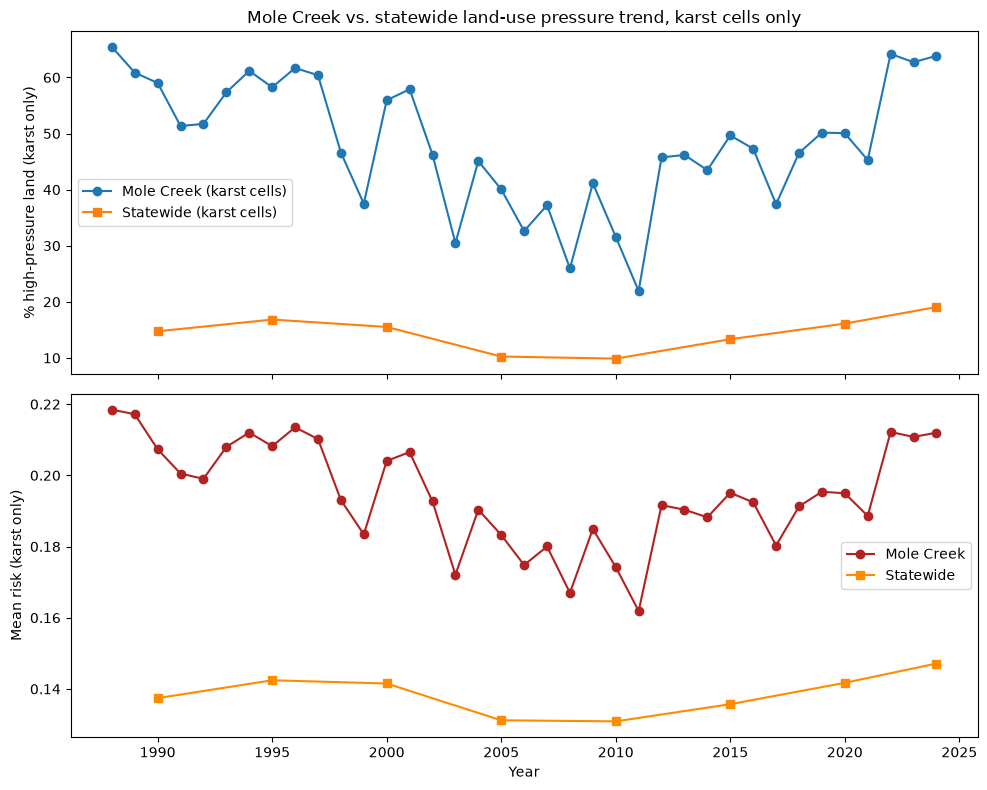

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axes[0].plot(mc_trend["year"], mc_trend["pct_high_pressure_karst"], marker="o", label="Mole Creek (karst cells)")
axes[0].plot(tas_trend["year"], tas_trend["pct_high_pressure_karst"], marker="s", label="Statewide (karst cells)")
axes[0].set_ylabel("% high-pressure land (karst only)")
axes[0].legend()
axes[0].set_title("Mole Creek vs. statewide land-use pressure trend, karst cells only")
axes[1].plot(mc_trend["year"], mc_trend["mean_risk_karst"], marker="o", color="firebrick", label="Mole Creek")
axes[1].plot(tas_trend["year"], tas_trend["mean_risk_karst"], marker="s", color="darkorange", label="Statewide")
axes[1].set_ylabel("Mean risk (karst only)")
axes[1].set_xlabel("Year")
axes[1].legend()
plt.tight_layout()
plt.show()

**Result:** the statewide series shows the same U-shape on karst cells.

The match between two series at different resolutions and extents could reflect a shared DEA product artefact, such as a classification change in that era, rather than two independent land-management signals. This is a limitation for `discussion.md`.

## Stage 9 summary

- **Catchment aggregation is the largest sensitivity.** Aggregated pressure correlates with raw-pixel pressure at only r = 0.092 over the Mole Creek karst, well below any weight variant (r 0.973 to 0.998).
- **Weight emphasis produces smaller shifts.** The broad pattern holds and the order of the three Mole Creek areas is the same in every scenario.
- **Rainfall cannot be tested within Mole Creek,** because it varies by only about 11 mm across the karst. An earlier rank flip involving Lorinna came from including a neighbouring system and from min-max scaling, and no longer appears now that results cover the Mole Creek karst only.
- **The land-use trend is U-shaped,** and clearer on karst cells (65% high-pressure land in 1988, 22% in 2011, 64% in 2024) than over the whole buffer.
- **The spatial pattern of risk is very stable year to year** (r > 0.9998), while the overall level swings substantially.
- **The cross-scale U-shape match** may reflect a shared data artefact.

## Stage 9 outputs

- `stage9_mole_creek_trend.csv` — 1988–2024 annual trend: high-pressure share for the whole buffer and for the Mole Creek karst, and mean risk on the karst
- `stage9_statewide_trend.csv` — statewide trend, 5-year steps, whole-area and karst-only metrics
